In [1]:
import numpy as np
import scipy
import seaborn as sns
from scipy.stats import norm
from collections import defaultdict
from matplotlib import pyplot as plt
from tqdm import tqdm
from pathlib import Path
import torch
from torch.utils.data import DataLoader

import sys
sys.path.append('../../src')
root = Path('../../src')
from utils.yaml import parse_yaml
from utils.utils import load_checkpoint
from metrics.testing import hsic
device = torch.device('cuda:0')

In [2]:
DATASET = 'sinusoid'
CRITIC = 'hsic'

# hyperparams
DATASIZE = 20000
TESTSIZES = [100, 200, 300, 400, 500]  # [100, 200, 300, 400, 500] # [750, 1000, 1250, 1500] 
NTEST = 500
NPERM = 200
NBOOT = 1000
ALPHA = 0.05

power = dict()
power['asymp'] = defaultdict(dict)
power['empir'] = defaultdict(dict)
power['perm'] = defaultdict(dict)

## Load Model and Dataset

In [3]:
# dataset
dataset_cfg = dict()
dataset_cfg['riab'] = root/"config/dataset/riab/riab.present.5000.yml"
dataset_cfg['sinusoid'] = root/"config/dataset/sinusoid/sinusoid-generator.yml"
dataset_cfg['hdgm4'] = root/"config/dataset/hdgm/hdgm4-generator.yml"

# model architectures
model_cfg = defaultdict(dict)
model_cfg['riab'] = root/"config/model/hsic/mlp8x32x64x32-mlp2x4x8x4.yml"
model_cfg['sinusoid'] = root/"config/model/hsic/mlp1x8x12x8-squared.yml"
model_cfg['hdgm4'] = root/"config/model/hsic/mlp2x4x6x4-squared.yml"

# pretrained paths
pretrain_pth = defaultdict(dict)
pretrain_pth['riab'] = "pretrained/hsic-riab.pt"
pretrain_pth['sinusoid'] = "pretrained/hsic-sinusoid.pt"
pretrain_pth['hdgm4'] = "pretrained/hsic-hdgm4.pt"

In [4]:
model = {
    'k': parse_yaml(model_cfg[DATASET])['k'].build(),
    'l': parse_yaml(model_cfg[DATASET])['l'].build(),
}
load_checkpoint(pretrain_pth[DATASET], (model['k'], model['l']), device=device)
model['k'].double()
model['l'].double()
model['k'].to(device)
model['l'].to(device)
model['k'].eval()
model['l'].eval()

dataconfig = parse_yaml(dataset_cfg[DATASET])['test']
if 'root' in dataconfig:
    dataconfig['root'] = root/dataconfig['root']
dataset = dataconfig.build()

def stream(dataloader):
    while True:
        yield from dataloader
loader_args = {'shuffle': True, 'drop_last': True} if DATASET == 'riab' else {}

## Permutation Test

In [5]:
@torch.no_grad
def perm_power(m, n_test, n_perm, alpha):
    testloader = stream(DataLoader(dataset, batch_size=m, **loader_args))
    n_reject = 0

    for t, data in tqdm(zip(range(n_test), testloader), total=n_test):
        X, Y = data
        X = X.to(device)
        Y = Y.to(device)

        hsic_est, var_est, p_value, r = hsic.permutation_test(model['k'], model['l'], X, Y, n_permutations=n_perm, significance=alpha)

        if p_value < alpha:
            n_reject += 1

    power = n_reject / n_test
    return power

for m in TESTSIZES:
    power['perm'][f'm={m}'] = perm_power(m, NTEST, NPERM, ALPHA)

100%|██████████| 500/500 [00:36<00:00, 13.79it/s]


## Empirical Threshold

In [6]:
# estimate null distribution quantile at sample size m

with torch.no_grad():
    threshes = dict()

    for m in TESTSIZES:
        dataloader = stream(DataLoader(dataset, batch_size=2*m, **loader_args))
        hsic_ests = np.full(NBOOT, np.nan)

        for i, data in tqdm(zip(range(NBOOT), dataloader), total=NBOOT):
            X, Y = data
            X = X.to(device)
            Y = Y.to(device)
            hsic_est, _ = hsic.hsic(model['k'], model['l'], X[:m], Y[m:], compute_var=False)
            hsic_ests[i] = hsic_est.cpu().numpy()

        threshes[f"m={m}"] = np.quantile(hsic_ests, 1-ALPHA)

100%|██████████| 1000/1000 [00:31<00:00, 31.87it/s]


In [7]:
# compute power based on the empirical threshold

with torch.no_grad():

    for m in TESTSIZES:
        dataloader = stream(DataLoader(dataset, batch_size=m, **loader_args))
        hsic_ests = np.full(NTEST, np.nan)

        for i, data in tqdm(zip(range(NTEST), dataloader), total=NTEST):
            X, Y = data
            X = X.to(device)
            Y = Y.to(device)
            hsic_est, _ = hsic.hsic(model['k'], model['l'], X, Y, compute_var=False)
            hsic_ests[i] = hsic_est.cpu().numpy()

        r_m = threshes[f"m={m}"]
        power['empir'][f'm={m}'] = (hsic_ests > r_m).mean()

100%|██████████| 500/500 [00:08<00:00, 60.57it/s]


## Asymptotic Formula

In [8]:
with torch.no_grad():
    DATASIZE=8000
    dataloader = DataLoader(dataset, batch_size=DATASIZE, **loader_args)
    data = next(iter(dataloader))
    del dataloader
    X, Y = data
    X = X.to(device)
    Y = Y.to(device)
    hsic_est, var_est = hsic.hsic(model['k'], model['l'], X, Y, compute_var=True)
    hsic_est = hsic_est.cpu().numpy()
    var_est = var_est.cpu().numpy()

@torch.no_grad
def asymp_power(m, alpha):
    r = threshes[f"m={m}"]
    sigma = np.sqrt(var_est)
    snr = hsic_est / sigma
    return norm.cdf( np.sqrt(m) * snr - np.sqrt(m) * (r / sigma) )

for m in TESTSIZES:
    power['asymp'][f'm={m}'] = asymp_power(m, ALPHA)

In [9]:
power

{'asymp': defaultdict(dict,
             {'m=100': 0.7823074994925234,
              'm=200': 0.979754855331347,
              'm=300': 0.9977429169342343,
              'm=400': 0.9997777410390645,
              'm=500': 0.9999781046282856}),
 'empir': defaultdict(dict,
             {'m=100': 0.738,
              'm=200': 0.99,
              'm=300': 0.998,
              'm=400': 1.0,
              'm=500': 1.0}),
 'perm': defaultdict(dict,
             {'m=100': 0.732,
              'm=200': 0.988,
              'm=300': 1.0,
              'm=400': 1.0,
              'm=500': 1.0})}

## Plots

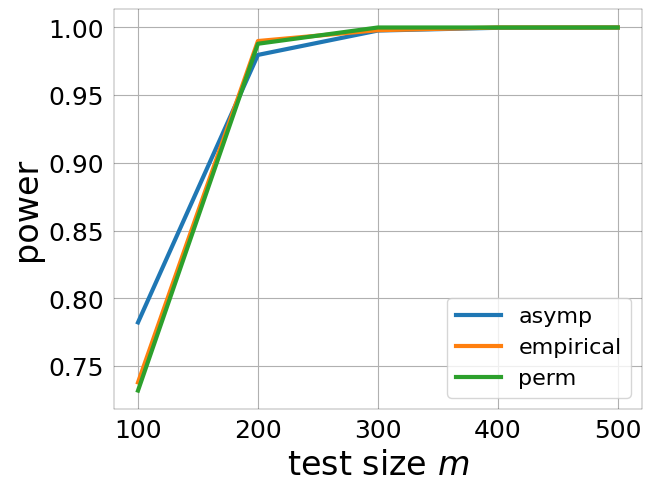

In [ ]:
fig, ax = plt.subplots(layout='constrained') #, figsize=(5, 5),)

power_asymp = list(power['asymp'].values())
power_empir = list(power['empir'].values())
power_perm = list(power['perm'].values())

ax.plot(TESTSIZES, power_asymp, linewidth=3, label='asymp', color='C0')
ax.plot(TESTSIZES, power_empir, linewidth=3, label='empirical', color='C1')
ax.plot(TESTSIZES, power_perm, linewidth=3, label='perm', color='C2')

# ax.set_title(f'{DATASET}: {CRITIC}' )
# ax.annotate(f'correlation: {corr:.0%}', xy=(0.99, 0.02), xycoords='axes fraction', ha='right')

# ax.set_ylim([0.4, 0.9])
ax.set_xlabel(r'test size $m$', fontsize=24)
ax.set_ylabel(r'power', fontsize=24)
ax.legend(fontsize=16, loc='lower right')

plt.grid()
plt.rcParams['axes.linewidth'] = 0.2
plt.tick_params(left=False, labelsize=18)
plt.tick_params(bottom=False, labelsize=18)


# plt.savefig(f'{CRITIC}-asymptotics-{DATASET}-2.pdf', bbox_inches='tight')